# Preliminary EDA — Defactify (MS COCOAI) for AI-Generated Image Detection

**Project:** Mad-Eye Moody Lens (IT314, Group 35) · **Scope:** image side, dataset selection + preliminary EDA
**Dataset:** [`Rajarshi-Roy-research/Defactify_Image_Dataset`](https://huggingface.co/datasets/Rajarshi-Roy-research/Defactify_Image_Dataset) (96k images: real MS COCO photos + 5 generators)
**Branch:** `shivam/defactify-preliminary-eda` (not merged into `main`)

**Question this notebook answers:** *Is Defactify useful and practical for our team, what role can it play in the benchmark stack, and what are its limits?*

**What this notebook does (CPU only, no model training):**
1. Streams a small, balanced, caption-paired sample from the `train` split (no full 7.5 GB download).
2. Builds a **raw** metadata table (`defactify_raw.csv`).
3. Cleans / validates it and adds flags + derived columns (`defactify_cleaned.csv`).
4. EDA: class balance, format / resolution / file-size profile, caption-paired samples, metadata-shortcut check, average FFT spectra per generator.
5. Prints an evidence-based summary to paste into the findings section.



In [1]:
!pip -q install datasets

In [2]:
import os, io, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image as PILImage

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

# ------------------------- CONFIG -------------------------
DATASET_ID = "Rajarshi-Roy-research/Defactify_Image_Dataset"
SPLIT      = "train"
N_ROWS     = 3000          # 500 caption groups x 6 images. Lower to 1200 if streaming is slow.
SEED       = 42
WORK_DIR   = "/content/dataset_analysis"
DATA_DIR   = f"{WORK_DIR}/data"
IMG_DIR    = "/content/defactify_sample"   # images stay here, NOT committed to Git
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(IMG_DIR, exist_ok=True)
rng = np.random.default_rng(SEED)

# Label definitions, taken from the official dataset card
#   Label_A: 0 = Real, 1 = AI-generated
#   Label_B: 0 = Real, 1 = SD 2.1, 2 = SDXL, 3 = SD 3, 4 = DALL-E 3, 5 = Midjourney v6
GEN_NAMES = {0: "Real", 1: "SD 2.1", 2: "SDXL", 3: "SD 3", 4: "DALL-E 3", 5: "Midjourney v6"}
# Family split follows the project's v3 spec. DALL-E 3 / Midjourney architectures are not public.
FAMILY = {0: "real", 1: "unet-diffusion", 2: "unet-diffusion", 3: "dit-flow-matching",
          4: "closed-undisclosed", 5: "closed-undisclosed"}
ORDER = [GEN_NAMES[i] for i in range(6)]

## 1. Load a sample (streaming)

The `train` split is ordered in caption groups of 6: one real COCO image followed by the five generated versions of the same caption. Taking the first `N_ROWS` rows therefore gives a **balanced, caption-paired** sample without downloading the full 7.5 GB. Images are written to local disk (not into the Git repo).

In [3]:
from datasets import load_dataset, Image as HFImage

ds = load_dataset(DATASET_ID, split=SPLIT, streaming=True)
print("Features:", ds.features)
ds = ds.cast_column("Image", HFImage(decode=False))   # keep original encoded bytes -> true file size/format

def sniff_ext(b: bytes) -> str:
    if b[:3] == b"\xff\xd8\xff": return "jpg"
    if b[:8] == b"\x89PNG\r\n\x1a\n": return "png"
    if b[:4] == b"RIFF" and b[8:12] == b"WEBP": return "webp"
    return "bin"

records = []
for i, row in enumerate(ds.take(N_ROWS)):
    im = row["Image"]
    b = im.get("bytes")
    if b is None and im.get("path"):
        b = open(im["path"], "rb").read()
    fname = f"img_{i:05d}.{sniff_ext(b)}"
    with open(os.path.join(IMG_DIR, fname), "wb") as f:
        f.write(b)
    records.append(dict(sample_id=i, filename=fname, caption=row["Caption"],
                        label_a=int(row["Label_A"]), label_b=int(row["Label_B"]),
                        file_size_bytes=len(b), md5=hashlib.md5(b).hexdigest()))
    if (i + 1) % 500 == 0:
        print(f"  streamed {i + 1}/{N_ROWS}")
print("Done:", len(records), "records ->", IMG_DIR)

README.md:   0%|          | 0.00/5.11k [00:00<?, ?B/s]

Features: {'Caption': Value('string'), 'Image': Image(mode=None, decode=True), 'Label_A': Value('int32'), 'Label_B': Value('int32')}
  streamed 500/3000
  streamed 1000/3000
  streamed 1500/3000
  streamed 2000/3000
  streamed 2500/3000
  streamed 3000/3000
Done: 3000 records -> /content/defactify_sample


## 2. Raw metadata table

One row per sampled image, exactly as delivered (no rows removed). Adds only what has to be measured from the file itself: dimensions, mode, encoded format, readability, and a caption-group id.

In [4]:
rows = []
for r in records:
    info = dict(r)
    path = os.path.join(IMG_DIR, r["filename"])
    try:
        with PILImage.open(path) as im:
            info.update(width=im.width, height=im.height, mode=im.mode, format=im.format)
            im.load()                                   # forces a full decode -> catches truncated files
            g = np.asarray(im.convert("L").resize((64, 64)), dtype=np.float32)
            info.update(mean_brightness=float(g.mean()), std_brightness=float(g.std()))
        info["readable"] = True
    except Exception as e:
        info.update(readable=False, error=str(e)[:80])
    rows.append(info)

raw = pd.DataFrame(rows)
raw["caption_group"] = (raw["caption"] != raw["caption"].shift()).cumsum() - 1
raw_path = f"{DATA_DIR}/defactify_raw.csv"
raw.to_csv(raw_path, index=False)
print("Saved", raw_path, raw.shape)
raw.head()

Saved /content/dataset_analysis/data/defactify_raw.csv (3000, 15)


,sample_id,filename,caption,label_a,label_b,file_size_bytes,md5,width,height,mode,format,mean_brightness,std_brightness,readable,caption_group
0,0,img_00000.jpg,Two tall giraffe standing next to each other o...,0,0,100832,7d483e695078d789430c0550343793c6,640,480,RGB,JPEG,96.276123,54.195934,True,0
1,1,img_00001.jpg,Two tall giraffe standing next to each other o...,1,1,80714,76431d90c4081f9998f3c2a00bc8bb77,768,768,RGB,JPEG,114.491943,38.521961,True,0
2,2,img_00002.jpg,Two tall giraffe standing next to each other o...,1,2,84767,25bbde9c922177fc3ac1365c6a40e778,1024,1024,RGB,JPEG,155.942139,44.412895,True,0
3,3,img_00003.jpg,Two tall giraffe standing next to each other o...,1,3,118619,c036938545abf8455f51a6e842bcbf10,1024,1024,RGB,JPEG,186.053223,47.654129,True,0
4,4,img_00004.jpg,Two tall giraffe standing next to each other o...,1,4,12176,6514523464cabe72ed322ed449c387ef,270,270,RGB,JPEG,131.318359,57.236347,True,0


In [5]:
print("Rows:", len(raw), "| Columns:", list(raw.columns))
print("\nMissing values per column:"); print(raw.isna().sum()[raw.isna().sum() > 0].to_string() or "none")
print("\nLabel_B counts:"); print(raw["label_b"].map(GEN_NAMES).value_counts().reindex(ORDER).to_string())
print("\nEncoded formats:"); print(raw["format"].value_counts(dropna=False).to_string())

Rows: 3000 | Columns: ['sample_id', 'filename', 'caption', 'label_a', 'label_b', 'file_size_bytes', 'md5', 'width', 'height', 'mode', 'format', 'mean_brightness', 'std_brightness', 'readable', 'caption_group']

Missing values per column:
Series([], )

Label_B counts:
label_b
Real             500
SD 2.1           500
SDXL             500
SD 3             500
DALL-E 3         500
Midjourney v6    500

Encoded formats:
format
JPEG    3000


## 3. Cleaning and validation

Rows are **dropped** only when they are unusable: unreadable files, `Label_A`/`Label_B` contradictions, exact byte-duplicates. Everything suspicious-but-usable is **flagged**, not deleted, so the ML team can decide. Each step is logged.

The dataset's Hugging Face community tab carries a report that some images are mislabeled, so a metadata-only screen for this is included (`suspect_label`). It is a screening heuristic, not proof.

In [6]:
df = raw.copy()
log = [("raw rows", len(df))]

# 1) unreadable / corrupt
bad = ~df["readable"]
df = df[~bad].copy(); log.append(("dropped: unreadable/corrupt", int(bad.sum())))
df[["width", "height"]] = df[["width", "height"]].astype(int)   # NaNs from unreadable rows made these floats

# 2) Label_A vs Label_B contradiction  (Real must be 0 in both, AI must be non-zero in Label_B)
inc = (df["label_a"] == 0) != (df["label_b"] == 0)
df = df[~inc].copy(); log.append(("dropped: label_a/label_b contradiction", int(inc.sum())))

# 3) exact duplicates (same bytes). Keep first occurrence.
dup = df.duplicated("md5", keep="first")
df = df[~dup].copy(); log.append(("dropped: exact duplicate files", int(dup.sum())))

# ---- derived columns
df["generator"]        = df["label_b"].map(GEN_NAMES)
df["generator_family"] = df["label_b"].map(FAMILY)
df["is_ai"]            = df["label_a"].astype(bool)
df["aspect_ratio"]     = (df["width"] / df["height"]).round(3)
df["megapixels"]       = (df["width"] * df["height"] / 1e6).round(3)
df["bytes_per_pixel"]  = (df["file_size_bytes"] / (df["width"] * df["height"])).round(4)
df["file_size_kb"]     = (df["file_size_bytes"] / 1024).round(1)
df["caption_words"]    = df["caption"].fillna("").str.split().str.len()

# ---- flags (rows are kept)
df["empty_caption"] = df["caption"].fillna("").str.strip().eq("")
grp = df.groupby("caption_group")["label_b"].agg(lambda s: set(s) == set(range(6)) and len(s) == 6)
df["group_complete"] = df["caption_group"].map(grp)      # True -> real + all 5 generators present for that caption

q1 = df.groupby("label_b")["file_size_bytes"].transform(lambda s: s.quantile(0.25))
q3 = df.groupby("label_b")["file_size_bytes"].transform(lambda s: s.quantile(0.75))
iqr = q3 - q1
df["size_outlier"] = (df["file_size_bytes"] < q1 - 1.5 * iqr) | (df["file_size_bytes"] > q3 + 1.5 * iqr)

# metadata-signature screen: a (format, width, height) signature that is >=98% one class,
# but the row carries the opposite label -> candidate mislabel (needs visual review)
df["meta_signature"] = df["format"].astype(str) + "_" + df["width"].astype(str) + "x" + df["height"].astype(str)
sig = df.groupby("meta_signature")["label_a"].agg(["count", "mean"])
sig = sig[sig["count"] >= 5]
df["sig_ai_share"] = df["meta_signature"].map(sig["mean"])
df["suspect_label"] = ((df["sig_ai_share"] >= 0.98) & (df["label_a"] == 0)) | ((df["sig_ai_share"] <= 0.02) & (df["label_a"] == 1))

log.append(("cleaned rows", len(df)))
for k in ["empty_caption", "size_outlier", "suspect_label"]:
    log.append((f"flagged: {k}", int(df[k].sum())))
log.append(("flagged: rows in incomplete caption groups", int((~df["group_complete"]).sum())))

cleaned_path = f"{DATA_DIR}/defactify_cleaned.csv"
df.drop(columns=["readable", "error"], errors="ignore").to_csv(cleaned_path, index=False)
print("Saved", cleaned_path, df.shape)
pd.DataFrame(log, columns=["step", "rows"])

Saved /content/dataset_analysis/data/defactify_cleaned.csv (3000, 29)


,step,rows
0,raw rows,3000
1,dropped: unreadable/corrupt,0
2,dropped: label_a/label_b contradiction,0
3,dropped: exact duplicate files,0
4,cleaned rows,3000
5,flagged: empty_caption,0
6,flagged: size_outlier,25
7,flagged: suspect_label,0
8,flagged: rows in incomplete caption groups,0


## 4. EDA

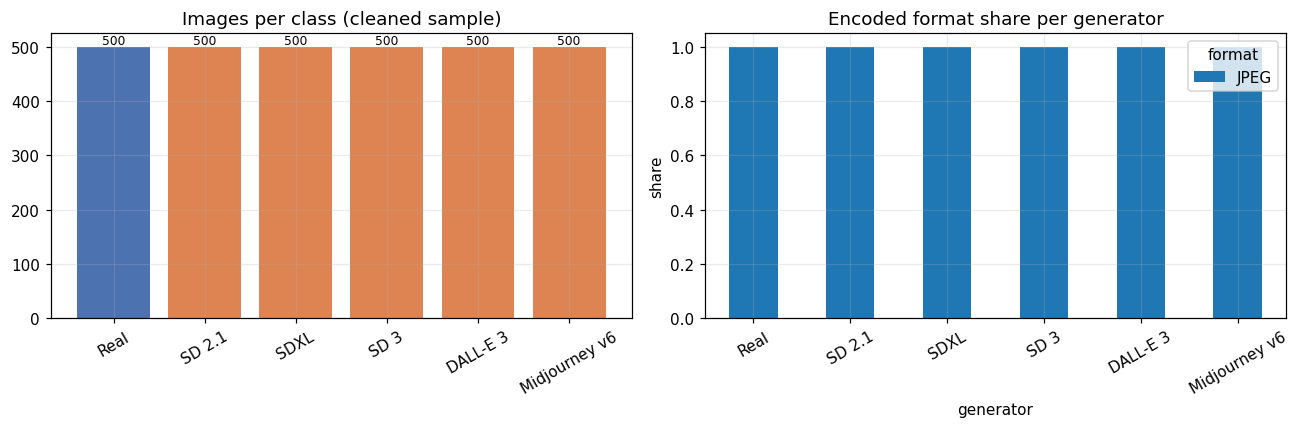

In [7]:
# 4.1 Class balance + encoded format per generator
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
counts = df["generator"].value_counts().reindex(ORDER)
ax[0].bar(counts.index, counts.values, color=["#4c72b0"] + ["#dd8452"] * 5)
ax[0].set_title("Images per class (cleaned sample)"); ax[0].tick_params(axis="x", rotation=30)
for i, v in enumerate(counts.values): ax[0].text(i, v, str(v), ha="center", va="bottom", fontsize=8)

fmt = pd.crosstab(df["generator"], df["format"], normalize="index").reindex(ORDER)
fmt.plot(kind="bar", stacked=True, ax=ax[1], rot=30)
ax[1].set_title("Encoded format share per generator"); ax[1].set_ylabel("share"); ax[1].legend(title="format")
plt.tight_layout(); plt.show()

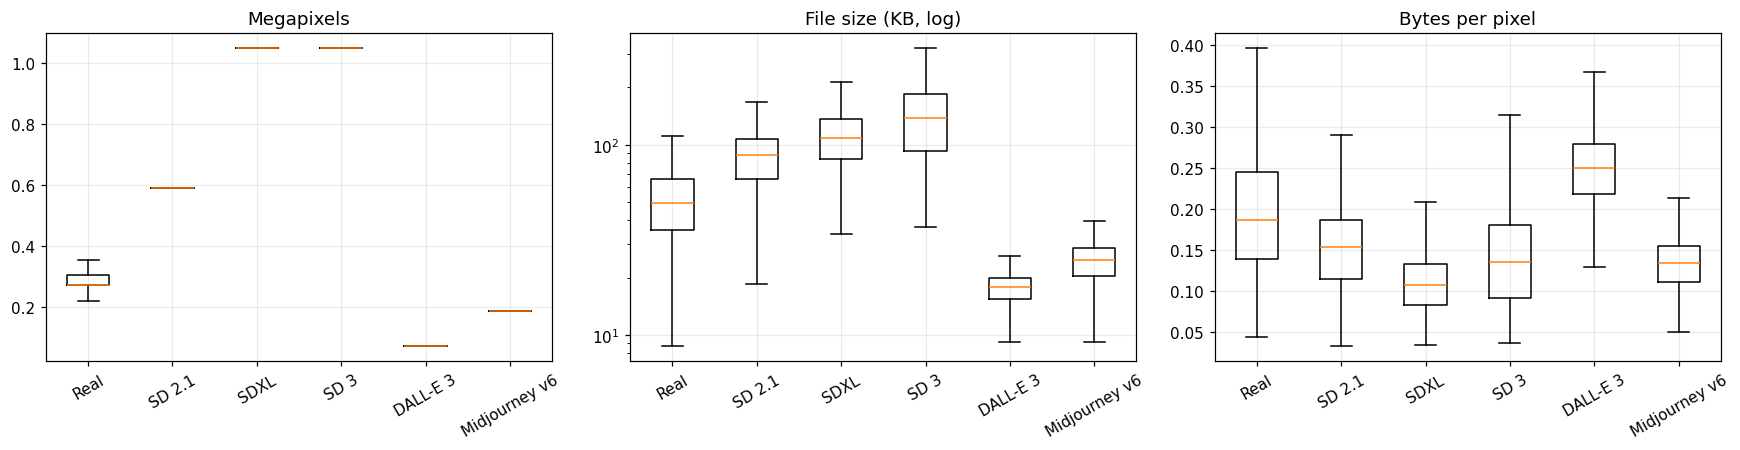

Most common (format, width x height) per generator:
generator
Real             JPEG_640x480 (21%), JPEG_640x427 (13%), JPEG_4...
SD 2.1                                         JPEG_768x768 (100%)
SDXL                                         JPEG_1024x1024 (100%)
SD 3                                         JPEG_1024x1024 (100%)
DALL-E 3                    JPEG_270x270 (100%), JPEG_351x351 (0%)
Midjourney v6                                  JPEG_436x436 (100%)


In [8]:
# 4.2 Resolution and file size per generator
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
data = [df.loc[df["generator"] == g, "megapixels"] for g in ORDER]
ax[0].boxplot(data, labels=ORDER, showfliers=False); ax[0].set_title("Megapixels"); ax[0].tick_params(axis="x", rotation=30)
data = [df.loc[df["generator"] == g, "file_size_kb"] for g in ORDER]
ax[1].boxplot(data, labels=ORDER, showfliers=False); ax[1].set_yscale("log"); ax[1].set_title("File size (KB, log)"); ax[1].tick_params(axis="x", rotation=30)
data = [df.loc[df["generator"] == g, "bytes_per_pixel"] for g in ORDER]
ax[2].boxplot(data, labels=ORDER, showfliers=False); ax[2].set_title("Bytes per pixel"); ax[2].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

print("Most common (format, width x height) per generator:")
top = (df.groupby("generator")["meta_signature"].agg(lambda s: ", ".join(f"{k} ({v/len(s):.0%})" for k, v in s.value_counts().head(3).items()))
         .reindex(ORDER))
print(top.to_string())

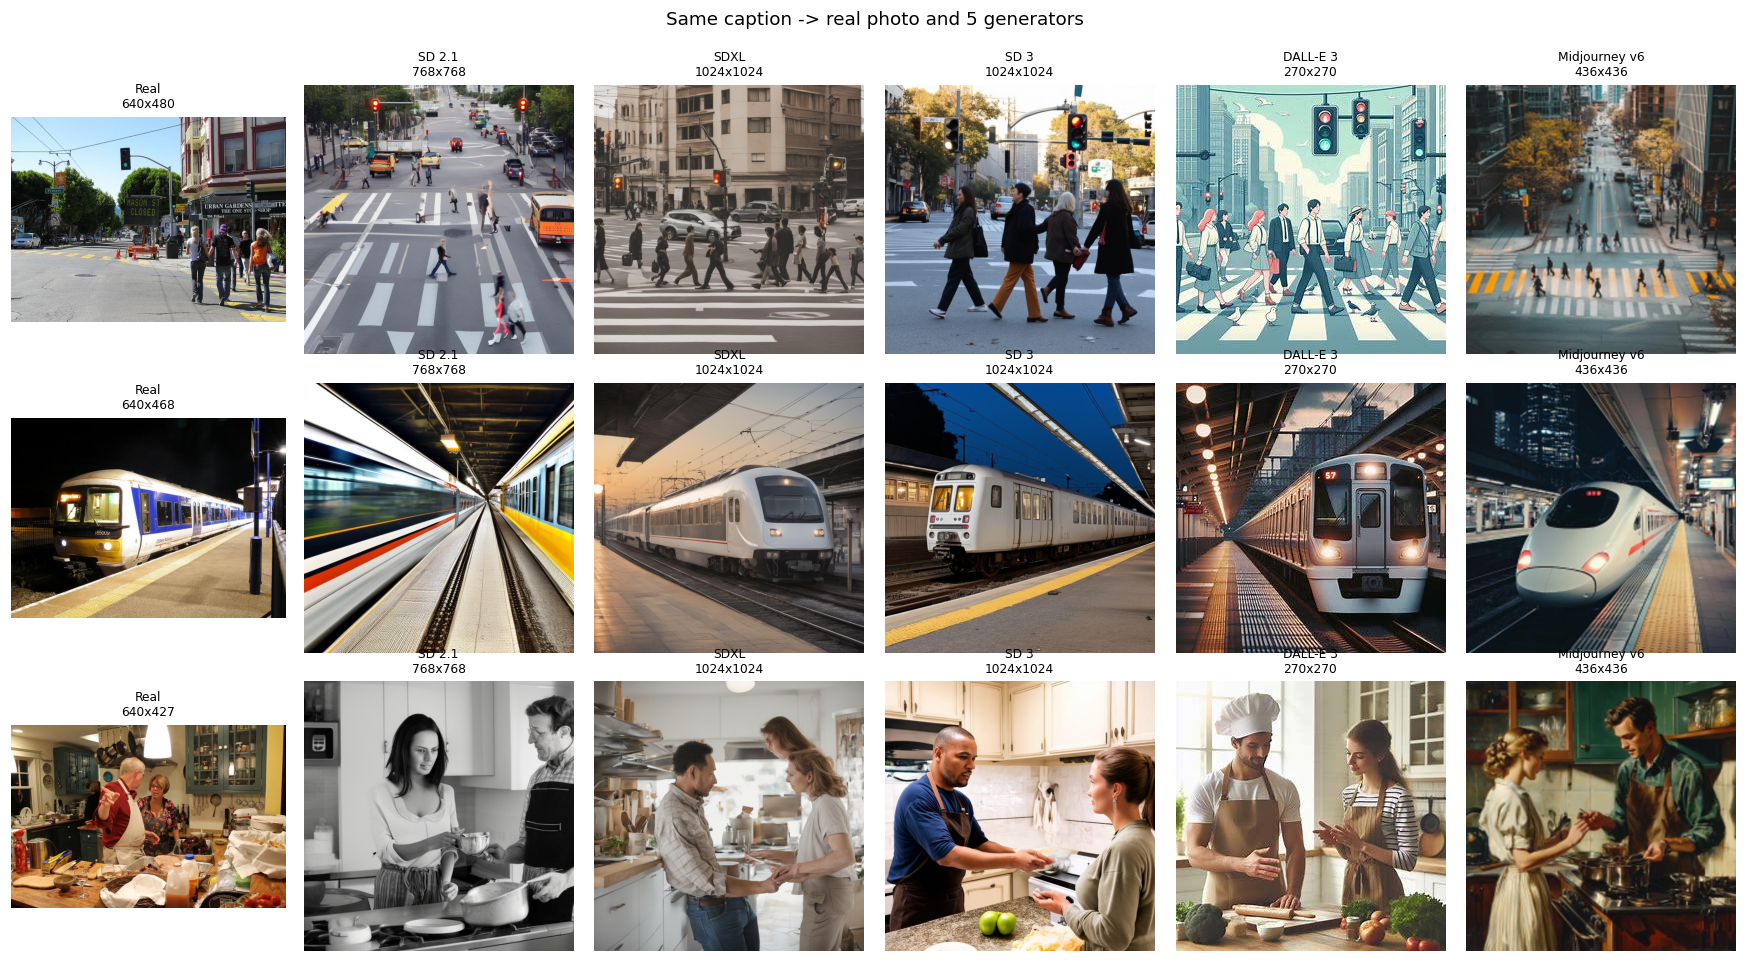

In [9]:
# 4.3 Caption-paired samples: same prompt, real + 5 generators
complete = df.loc[df["group_complete"], "caption_group"].unique()
picks = rng.choice(complete, size=min(3, len(complete)), replace=False)
fig, axes = plt.subplots(len(picks), 6, figsize=(16, 2.9 * len(picks)))
axes = np.atleast_2d(axes)
for r_i, gid in enumerate(picks):
    sub = df[df["caption_group"] == gid].sort_values("label_b")
    for c_i, (_, row) in enumerate(sub.iterrows()):
        im = PILImage.open(os.path.join(IMG_DIR, row["filename"])).convert("RGB")
        axes[r_i, c_i].imshow(im); axes[r_i, c_i].axis("off")
        axes[r_i, c_i].set_title(f"{row['generator']}\n{row['width']}x{row['height']}", fontsize=8)
    axes[r_i, 0].set_ylabel(sub["caption"].iloc[0][:40])
plt.suptitle("Same caption -> real photo and 5 generators", y=1.0); plt.tight_layout(); plt.show()

In [10]:
# 4.4 Flagged (suspect_label) rows - visual review
sus = df[df["suspect_label"]].head(8)
print("suspect_label rows:", int(df["suspect_label"].sum()), "of", len(df))
if len(sus):
    fig, axes = plt.subplots(2, 4, figsize=(14, 7)); axes = axes.ravel()
    for ax in axes: ax.axis("off")
    for ax, (_, row) in zip(axes, sus.iterrows()):
        ax.imshow(PILImage.open(os.path.join(IMG_DIR, row["filename"])).convert("RGB"))
        ax.set_title(f"labelled: {row['generator']}\n{row['meta_signature']}", fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print("No suspect rows flagged in this sample.")

suspect_label rows: 0 of 3000
No suspect rows flagged in this sample.


In [11]:
# 4.5 Metadata shortcut check
# If a tiny tree on width/height/file size/format separates real from AI, a detector can "cheat" on
# container metadata instead of learning generation artifacts -> must normalise (resize / re-encode) before training.
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GroupKFold, cross_val_score

X = pd.DataFrame({"width": df["width"], "height": df["height"], "file_size_bytes": df["file_size_bytes"],
                  "is_jpeg": (df["format"] == "JPEG").astype(int), "bytes_per_pixel": df["bytes_per_pixel"]})
groups = df["caption_group"]
cv = GroupKFold(n_splits=5)
tree = DecisionTreeClassifier(max_depth=3, random_state=SEED, class_weight="balanced")

acc_bin = cross_val_score(tree, X, df["label_a"], groups=groups, cv=cv, scoring="balanced_accuracy").mean()
acc_gen = cross_val_score(tree, X, df["label_b"], groups=groups, cv=cv, scoring="balanced_accuracy").mean()
print(f"Real vs AI  from metadata only (balanced acc): {acc_bin:.3f}   (chance = 0.500)")
print(f"6-way generator from metadata only (bal. acc): {acc_gen:.3f}   (chance = {1/6:.3f})")

Real vs AI  from metadata only (balanced acc): 0.997   (chance = 0.500)
6-way generator from metadata only (bal. acc): 0.710   (chance = 0.167)


Real           images used: 150
SD 2.1         images used: 150
SDXL           images used: 150
SD 3           images used: 150
DALL-E 3       images used: 150
Midjourney v6  images used: 150


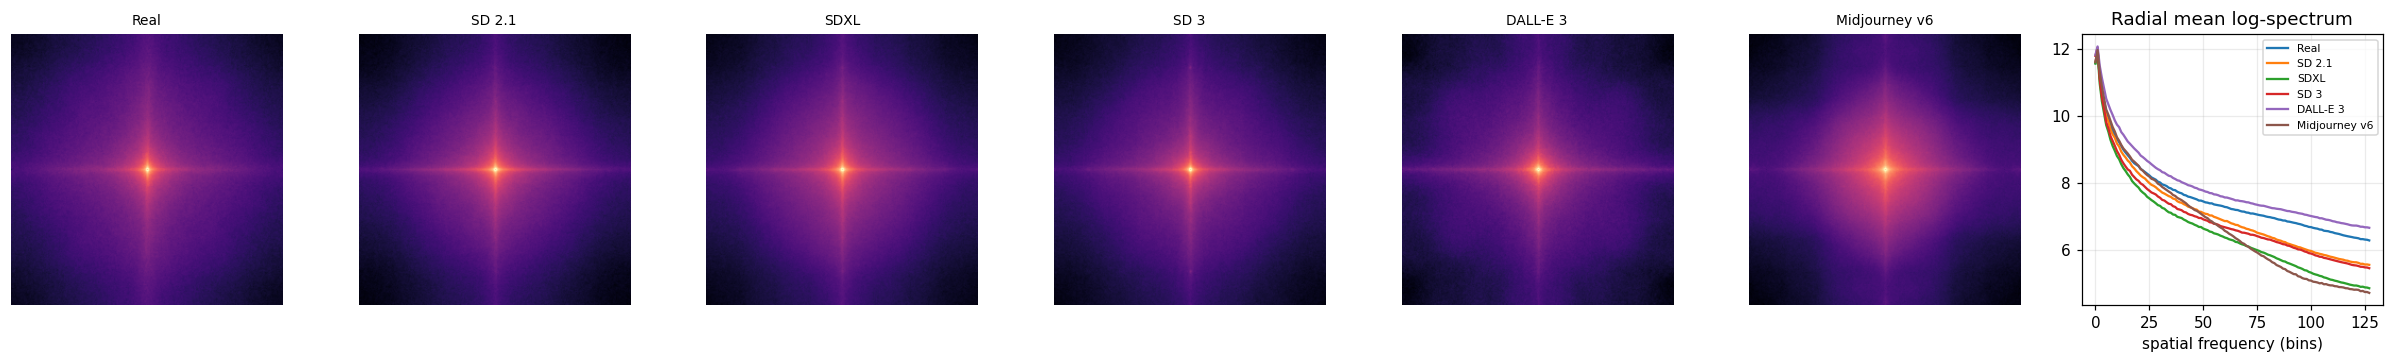

In [12]:
# 4.6 Average FFT spectrum per class (native pixels, centre 256x256 crop, Hann window; no resizing)
N_FFT, CROP = 150, 256
hann = np.outer(np.hanning(CROP), np.hanning(CROP))
yy, xx = np.indices((CROP, CROP)); rad = np.hypot(yy - CROP // 2, xx - CROP // 2).astype(int)
nbin = np.bincount(rad.ravel())

spec_mean, radial = {}, {}
for lab in range(6):
    acc, n = np.zeros((CROP, CROP)), 0
    sub = df[(df["label_b"] == lab) & (df["width"] >= CROP) & (df["height"] >= CROP)].head(N_FFT)
    for _, row in sub.iterrows():
        im = PILImage.open(os.path.join(IMG_DIR, row["filename"])).convert("L")
        w, h = im.size; l, t = (w - CROP) // 2, (h - CROP) // 2
        a = np.asarray(im.crop((l, t, l + CROP, t + CROP)), dtype=np.float64)
        a = (a - a.mean()) * hann
        acc += np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(a)))); n += 1
    if n:
        spec_mean[lab] = acc / n
        radial[lab] = np.bincount(rad.ravel(), weights=spec_mean[lab].ravel()) / nbin
    print(f"{GEN_NAMES[lab]:14s} images used: {n}")

fig, axes = plt.subplots(1, 7, figsize=(22, 3.4))
for i, lab in enumerate(sorted(spec_mean)):
    axes[i].imshow(spec_mean[lab], cmap="magma"); axes[i].set_title(GEN_NAMES[lab], fontsize=9); axes[i].axis("off")
for lab in sorted(radial):
    axes[6].plot(radial[lab][: CROP // 2], label=GEN_NAMES[lab])
axes[6].set_title("Radial mean log-spectrum"); axes[6].set_xlabel("spatial frequency (bins)"); axes[6].legend(fontsize=7)
plt.tight_layout(); plt.show()

## 5. Auto-generated summary (numbers to quote in the findings)

In [13]:
n = len(df)
fam = df["generator_family"].value_counts()
res = df.groupby("generator")[["width", "height"]].agg(lambda s: int(s.median())).reindex(ORDER)
print(f"Sample: {n} images from '{SPLIT}' split ({df['caption_group'].nunique()} caption groups)")
print(f"Dropped in cleaning: {len(raw) - n} of {len(raw)}")
print(f"Complete caption groups (real + 5 gens): {df.groupby('caption_group')['group_complete'].first().mean():.1%}")
print("\nClass counts:"); print(df['generator'].value_counts().reindex(ORDER).to_string())
print("\nFamily counts:"); print(fam.to_string())
print("\nMedian resolution (w, h):"); print(res.to_string())
print(f"\nFlags -> size_outlier: {int(df['size_outlier'].sum())} | suspect_label: {int(df['suspect_label'].sum())} | empty_caption: {int(df['empty_caption'].sum())}")
print(f"Metadata-only shortcut (balanced acc): real-vs-AI {acc_bin:.2f}, generator {acc_gen:.2f}")
print("\nFormat by class (row-normalised):"); print(pd.crosstab(df['generator'], df['format'], normalize='index').reindex(ORDER).round(2).to_string())

Sample: 3000 images from 'train' split (500 caption groups)
Dropped in cleaning: 0 of 3000
Complete caption groups (real + 5 gens): 100.0%

Class counts:
generator
Real             500
SD 2.1           500
SDXL             500
SD 3             500
DALL-E 3         500
Midjourney v6    500

Family counts:
generator_family
unet-diffusion        1000
closed-undisclosed    1000
real                   500
dit-flow-matching      500

Median resolution (w, h):
               width  height
generator                   
Real             640     480
SD 2.1           768     768
SDXL            1024    1024
SD 3            1024    1024
DALL-E 3         270     270
Midjourney v6    436     436

Flags -> size_outlier: 25 | suspect_label: 0 | empty_caption: 0
Metadata-only shortcut (balanced acc): real-vs-AI 1.00, generator 0.71

Format by class (row-normalised):
format         JPEG
generator          
Real            1.0
SD 2.1          1.0
SDXL            1.0
SD 3            1.0
DALL-E 3        1.0

## 6. Findings, suitability and limitations

### Structure and integrity

The preliminary EDA uses 3,000 records from the `train` split, corresponding to 500 complete caption groups. Each group contains one real image and five generated counterparts. The sample therefore preserves the caption-paired structure while representing each source equally: 500 real images and 500 images from each of the five synthetic generators. No unreadable images, exact duplicate files, label contradictions, or incomplete caption groups were detected during cleaning. Twenty-five rows were flagged as file-size outliers and retained for review rather than deleted.

### Format, resolution and file-size profile

All sampled images are JPEG/RGB images, but resolution varies substantially by source. Median resolution ranges from 270×270 for DALL-E 3 to 1024×1024 for SDXL and SD 3, while real images have a median resolution of 640×480. Mean file size also differs substantially across generators. These differences represent potential dataset shortcuts unrelated to the actual visual evidence of image generation.

### Metadata shortcut risk

A metadata-only decision-tree classifier using simple image properties achieved approximately 0.997 balanced accuracy for real-vs-AI classification and 0.710 balanced accuracy for six-way generator identification. This demonstrates strong source information in low-level metadata. A future detector should therefore standardize preprocessing, including image dimensions and encoding parameters, before training so that the model is less able to exploit container-level or resolution-related shortcuts.

### Spectral analysis

The FFT analysis provides an exploratory comparison of frequency-domain characteristics across the real images and the five synthetic sources. These observations are preliminary and are not evidence that a particular spectral feature is independently sufficient for classification. The results motivate further architecture-specific forensic analysis using frequency-domain features.

### Label quality

No samples were flagged by the notebook's metadata-based suspect-label heuristic. This indicates no obvious contradictions were found in the sampled metadata, but it does not establish that the complete dataset is free of label noise.

### Relevance to Mad-Eye Moody Lens

The dataset is useful for preliminary dataset analysis because it provides explicit real/AI labels, generator identity, and caption-matched real/generated images from multiple sources. It can therefore support analysis of generator-specific variation, dataset shortcuts, preprocessing requirements, and preliminary forensic feature investigation.

### Limitations

This analysis covers 3,000 training records rather than the complete dataset and uses the first 3,000 records because they form complete caption groups; it is not a random sample of the full training split. The real images originate from MS COCO, so the real-image distribution is limited to that source. The dataset does not reproduce social-media post-processing or the project's double-compression test condition. It also covers only five synthetic generators and does not cover GAN-based generation or video/audio modalities. These results are preliminary dataset-characterization findings and are not model-performance results.

## 7. Download outputs

In [14]:
print(raw_path, "->", os.path.getsize(raw_path) // 1024, "KB")
print(cleaned_path, "->", os.path.getsize(cleaned_path) // 1024, "KB")
try:
    from google.colab import files
    files.download(raw_path); files.download(cleaned_path)
except ImportError:
    print("Not running in Colab; files are in", DATA_DIR)

/content/dataset_analysis/data/defactify_raw.csv -> 515 KB
/content/dataset_analysis/data/defactify_cleaned.csv -> 773 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>